# Experiment 07 — Feature Importance (Task 4)

What's the model actually using to make decisions? This notebook covers Tasks 4.1–4.3 for the three models from Task 3.2.

- **LinearSVC** — look at the coefficients. Positive = pushes toward readmitted, negative = pushes away. Magnitude = how strongly.
- **Random Forest** — `feature_importances_` (mean decrease in impurity across all trees)
- **Gradient Boosting** — same as RF

We re-train the best configs from exp_05 here — no need to load from disk, sklearn models are fast enough to refit in seconds. Same 80/20 split, no test set needed for interpretation.

In [1]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    if not os.path.exists(REPO):
        os.system('git clone <your-repo-url>')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

from src.pipeline.load import load_full_df
from src.data.features import build_features

sns.set_theme(style='whitegrid')
FIGURES = Path('../../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

TOP_N = 20   # features to show per model

---
## Get the feature names

We call `build_features` directly instead of going through the pipeline — that way we get the column list back alongside the arrays, which we need for labelling the plots.

In [3]:
df = load_full_df()
split = int(0.8 * len(df))
df_train = df.iloc[:split].copy()
df_val   = df.iloc[split:].copy()

X_train, y_train, scaler, feature_names = build_features(df_train, fit_scaler=True)
X_val,   y_val,   _,      _             = build_features(df_val, scaler=scaler,
                                                          fit_scaler=False,
                                                          columns=feature_names)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Features ({len(feature_names)}):', feature_names[:8], '...')

Train : (57214, 94)
Val   : (14304, 94)
Features (94): ['gender', 'age', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient'] ...


---
## Refit the three models

Best configs from exp_05 — LinearSVM at C=0.01, RF at depth=12, GB at depth=6 lr=0.05.

In [4]:
linear_svm = LinearSVC(C=0.01, max_iter=2000, class_weight='balanced')
rf         = RandomForestClassifier(n_estimators=200, max_depth=12,
                                    class_weight='balanced', n_jobs=-1, random_state=42)
gb         = GradientBoostingClassifier(n_estimators=200, max_depth=6,
                                        learning_rate=0.05, subsample=0.8, random_state=42)

for name, model in [('LinearSVM', linear_svm), ('RF', rf), ('GB', gb)]:
    model.fit(X_train, y_train)
    print(f'{name} trained')

LinearSVM trained
RF trained
GB trained


---
## Task 4.1 — What are the models looking at?

### LinearSVC — coefficients

Each bar is a feature's coefficient. Red bars push the model toward predicting readmitted, blue bars push it away. Worth checking which direction makes clinical sense — if a feature like `discharge_group_expired` has a large negative coefficient that's suspicious (expired patients can't be readmitted).

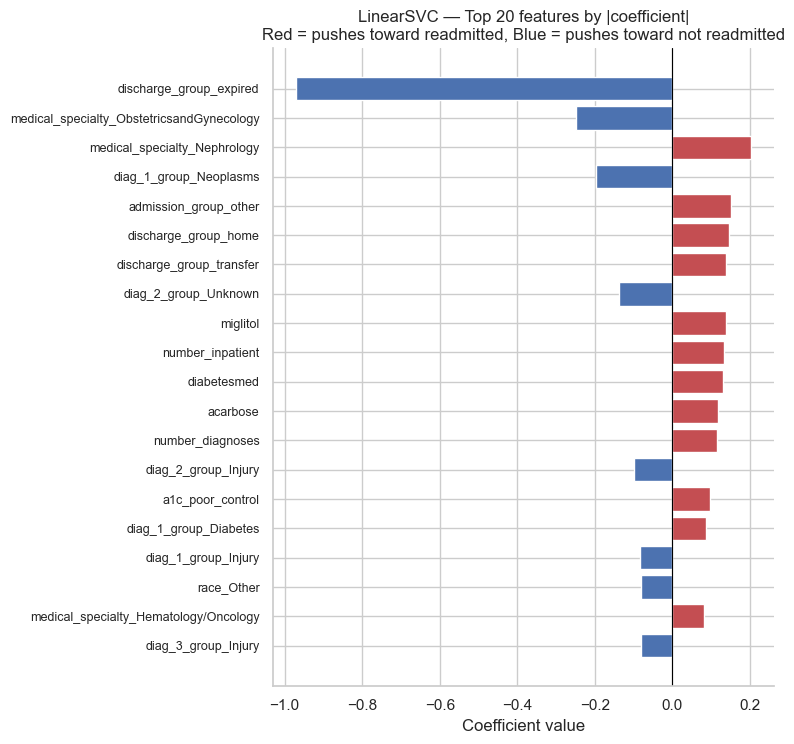

In [6]:
def plot_coefficients(model, feature_names, top_n=TOP_N, title='', save_path=None):
    coefs = model.coef_[0]
    idx   = np.argsort(np.abs(coefs))[-top_n:]
    vals  = coefs[idx]
    names = [feature_names[i] for i in idx]

    colors = ['#C44E52' if v > 0 else '#4C72B0' for v in vals]
    fig, ax = plt.subplots(figsize=(8, top_n * 0.38))
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient value')
    ax.set_title(title)
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.show()

plot_coefficients(
    linear_svm, feature_names,
    title=f'LinearSVC — Top {TOP_N} features by |coefficient|\n'
          f'Red = pushes toward readmitted, Blue = pushes toward not readmitted',
    save_path=FIGURES / 'feature_importance_linear_svm.png',
)

### Random Forest — feature importances

MDI (mean decrease in impurity) — no direction, just magnitude. One thing to keep in mind: MDI is biased toward high-frequency features, so `race_Caucasian` can score high just because 75% of rows are Caucasian. The permutation importance section below corrects for this.

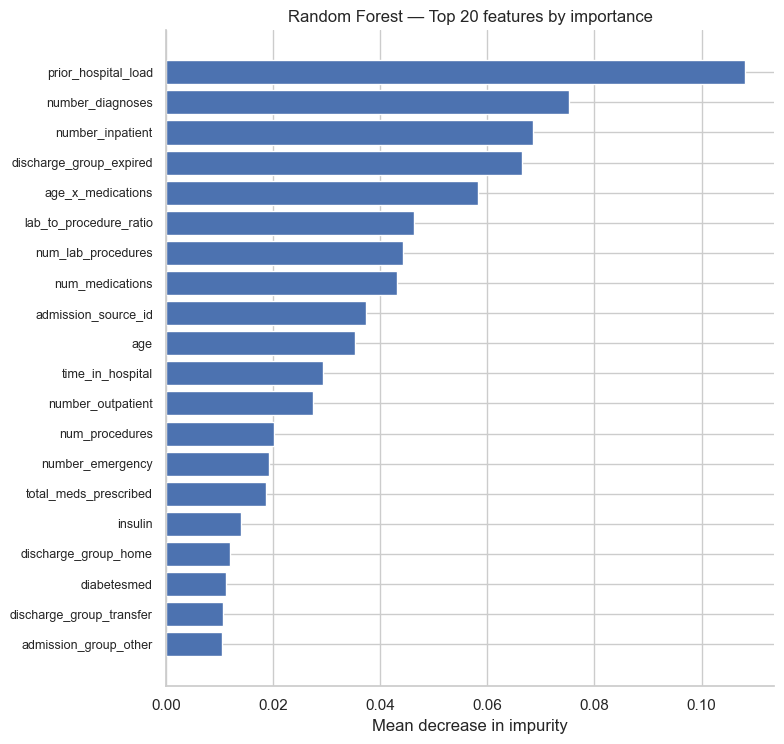

In [7]:
def plot_importances(model, feature_names, top_n=TOP_N, title='', save_path=None):
    imps  = model.feature_importances_
    idx   = np.argsort(imps)[-top_n:]
    vals  = imps[idx]
    names = [feature_names[i] for i in idx]

    fig, ax = plt.subplots(figsize=(8, top_n * 0.38))
    ax.barh(names, vals, color='#4C72B0')
    ax.set_xlabel('Mean decrease in impurity')
    ax.set_title(title)
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.show()

plot_importances(
    rf, feature_names,
    title=f'Random Forest — Top {TOP_N} features by importance',
    save_path=FIGURES / 'feature_importance_rf.png',
)

### Gradient Boosting — feature importances

Same MDI method as RF. Compare the rankings — GB and RF usually agree on the top features but differ in how steeply they rank them.

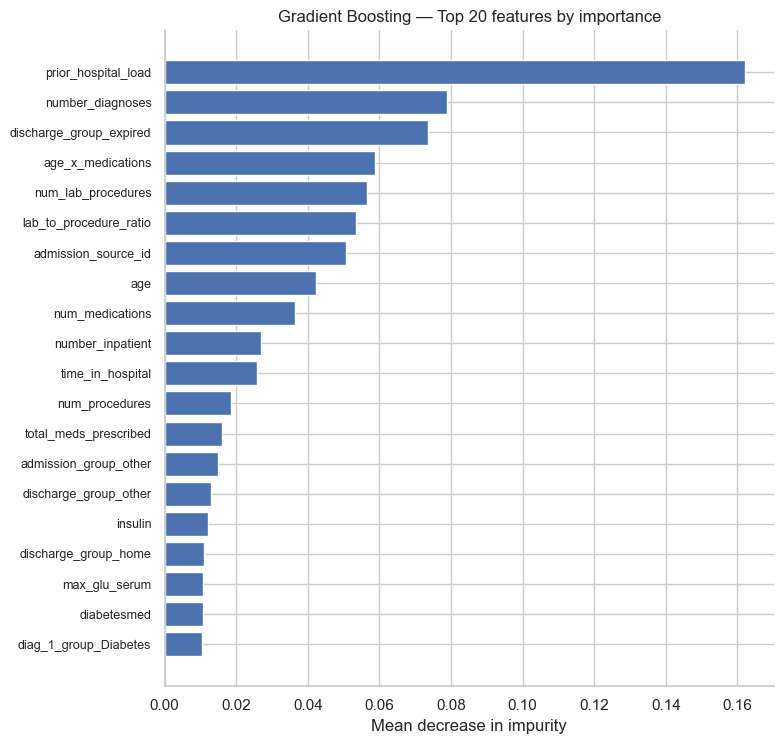

In [8]:
plot_importances(
    gb, feature_names,
    title=f'Gradient Boosting — Top {TOP_N} features by importance',
    save_path=FIGURES / 'feature_importance_gb.png',
)

### All three side by side

Normalised to [0, 1] so the scales are comparable across model families. The union of each model's top 20 is shown — features that only matter to one model are interesting to flag.

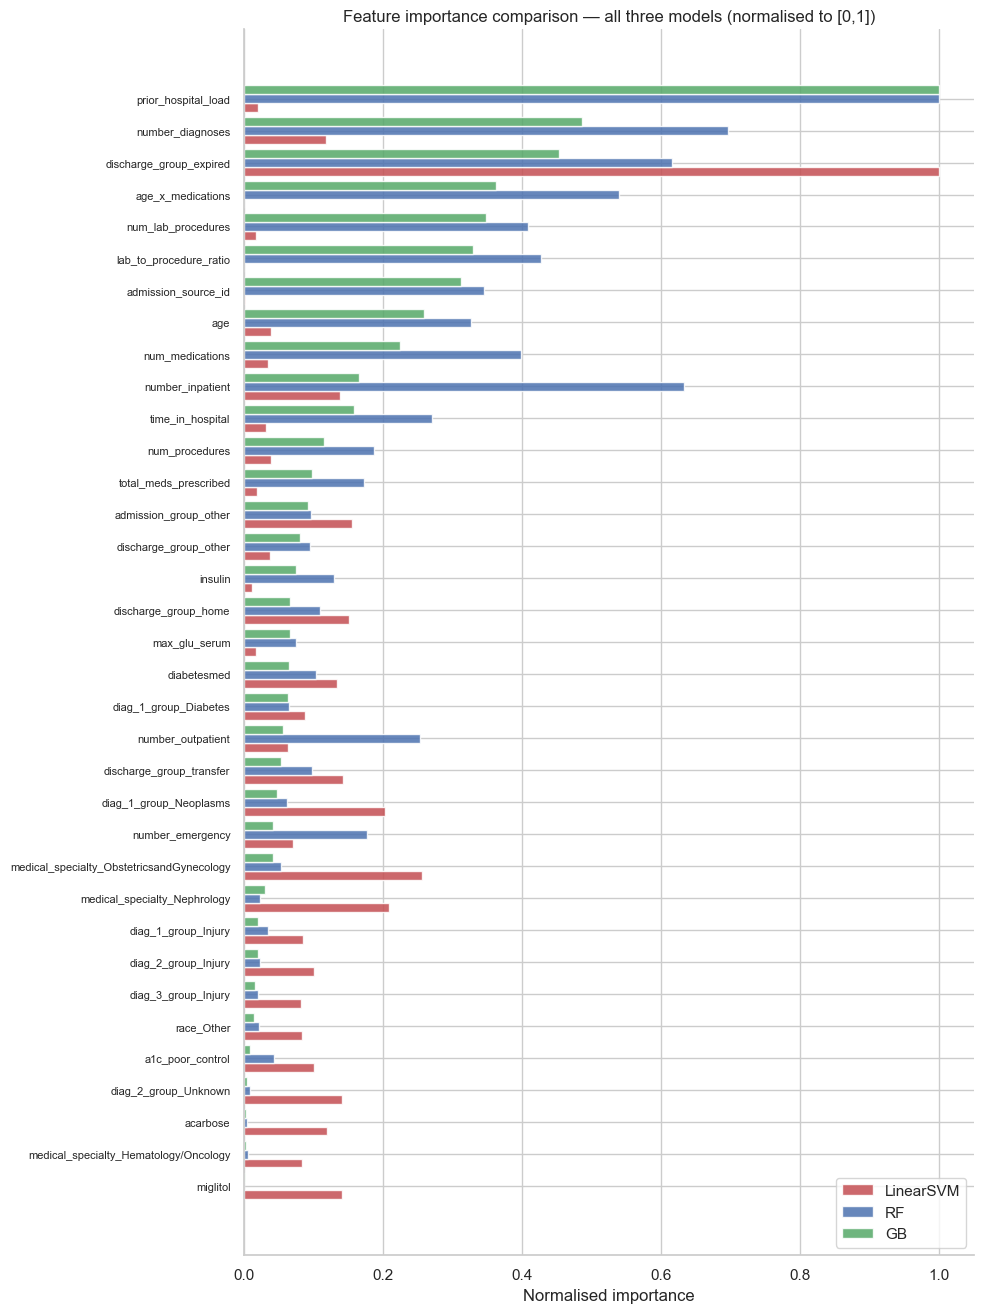

In [9]:
def normalised_importances(model, feature_names):
    """Return a Series of normalised importances (or |coef|) indexed by feature name."""
    if hasattr(model, 'feature_importances_'):
        vals = model.feature_importances_
    else:
        vals = np.abs(model.coef_[0])
    vals = vals / vals.max()
    return pd.Series(vals, index=feature_names)

imp_df = pd.DataFrame({
    'LinearSVM': normalised_importances(linear_svm, feature_names),
    'RF':        normalised_importances(rf,         feature_names),
    'GB':        normalised_importances(gb,         feature_names),
})

# Union of top-N from each model
top_features = set()
for col in imp_df.columns:
    top_features.update(imp_df[col].nlargest(TOP_N).index)

plot_df = imp_df.loc[list(top_features)].sort_values('GB', ascending=True)

fig, ax = plt.subplots(figsize=(10, len(plot_df) * 0.38))
x = np.arange(len(plot_df))
width = 0.28
colors = {'LinearSVM': '#C44E52', 'RF': '#4C72B0', 'GB': '#55A868'}

for k, (model_name, color) in enumerate(colors.items()):
    ax.barh(x + k * width, plot_df[model_name], width, label=model_name, color=color, alpha=0.85)

ax.set_yticks(x + width)
ax.set_yticklabels(plot_df.index, fontsize=8)
ax.set_xlabel('Normalised importance')
ax.set_title('Feature importance comparison — all three models (normalised to [0,1])')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Permutation importance — the fairer comparison

MDI has known problems (frequency bias, correlated features). Permutation importance sidesteps all of that — it just asks: if I randomly shuffle this feature on the val set, how much does AUC drop? Works the same way for all three models so the rankings are directly comparable.

Two things to keep in mind for interpreting the results:
- `admission_source_id` in the `"full"` featurizer is a numeric encoding of categorical codes — any importance it shows in LinearSVC is partly an artefact of the continuous treatment
- Rare binary features (e.g. `race_Asian` at 1%) are systematically underestimated — shuffling 1% of rows barely moves AUC regardless of true signal

Running on a 2k val subsample with 10 repeats — fast enough to be interactive.

In [10]:
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
X_sub, y_sub = X_val[sub_idx], y_val[sub_idx]

perm_results = {}
for name, model in [('LinearSVM', linear_svm), ('RF', rf), ('GB', gb)]:
    print(f'Permutation importance: {name}...')
    pi = permutation_importance(
        model, X_sub, y_sub,
        scoring='roc_auc',
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
    )
    perm_results[name] = pd.Series(pi.importances_mean, index=feature_names)

perm_df = pd.DataFrame(perm_results)
print('Done')

Permutation importance: LinearSVM...
Permutation importance: RF...
Permutation importance: GB...
Done


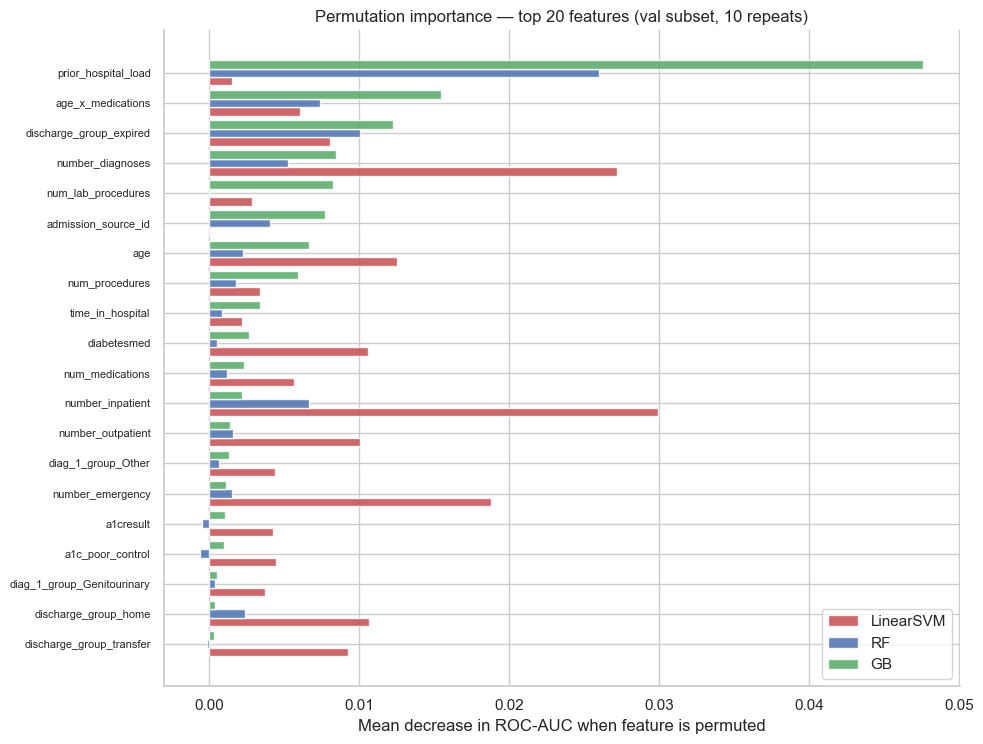

In [11]:
# Top features by mean permutation importance across all models
perm_df['mean'] = perm_df.mean(axis=1)
top_perm = perm_df.nlargest(TOP_N, 'mean').drop(columns='mean').sort_values('GB', ascending=True)

fig, ax = plt.subplots(figsize=(10, len(top_perm) * 0.38))
x = np.arange(len(top_perm))

for k, (model_name, color) in enumerate(colors.items()):
    ax.barh(x + k * width, top_perm[model_name], width, label=model_name, color=color, alpha=0.85)

ax.set_yticks(x + width)
ax.set_yticklabels(top_perm.index, fontsize=8)
ax.set_xlabel('Mean decrease in ROC-AUC when feature is permuted')
ax.set_title(f'Permutation importance — top {TOP_N} features (val subset, 10 repeats)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / 'permutation_importance_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Ranked table

Top 15 per model by permutation importance. Good starting point for spotting where the three models agree and where they diverge.

In [12]:
perm_df_clean = perm_df.drop(columns='mean', errors='ignore')

ranked = pd.DataFrame({
    model: perm_df_clean[model].nlargest(15).index.tolist()
    for model in ['LinearSVM', 'RF', 'GB']
})
display(ranked)

,LinearSVM,RF,GB
0,number_inpatient,prior_hospital_load,prior_hospital_load
1,number_diagnoses,discharge_group_expired,age_x_medications
2,number_emergency,age_x_medications,discharge_group_expired
3,age,number_inpatient,number_diagnoses
4,discharge_group_home,number_diagnoses,num_lab_procedures
5,diabetesmed,admission_source_id,admission_source_id
6,number_outpatient,discharge_group_home,age
7,discharge_group_transfer,age,num_procedures
8,discharge_group_expired,num_procedures,time_in_hospital
9,age_x_medications,number_outpatient,lab_to_procedure_ratio


---
## Task 4.2 — Where do the models agree, and where don't they?

*Fill this in after looking at the plots — notes below are a starting point.*

**What they probably all agree on:**
- `number_inpatient` and `prior_hospital_load` (the engineered sum of inpatient + emergency + outpatient) — prior hospital contact is the strongest signal regardless of model family
- `time_in_hospital`, `num_medications`, `num_diagnoses` — comorbidity burden shows up consistently
- `age_x_medications` (engineered interaction) — tree models tend to rank this highly; LinearSVC might split it differently

**Where they likely differ:**
- LinearSVC sees everything through a linear lens — it can't learn that `age` and `num_medications` interact, so it weights them separately. RF/GB can discover that combination directly via splits.
- MDI for RF/GB may show diag group dummies higher than permutation importance suggests — that's the frequency bias at work. Trust permutation importance more here.
- If `admission_source_id` ranks highly for LinearSVC but not in permutation importance, that's the numeric encoding artefact — flag it.

---
## Task 4.3 — Does any of this make clinical sense?

*Notes for the report — edit after seeing the actual rankings.*

**Features that make sense:**
- `number_inpatient` / `prior_hospital_load` — this is well-established in the literature. Patients who've been admitted before are more likely to come back. Strack et al. (2014) found the same on this dataset.
- `time_in_hospital` — longer stays usually mean more complex cases with harder recovery
- `num_medications` — polypharmacy is a proxy for how many things are going wrong at once
- `discharge_group_transfer` — being transferred to another facility rather than going home typically means the patient isn't well enough to manage independently
- `insulin_adjusted` — changing insulin dose during the stay suggests the diabetes wasn't under control
- `a1c_poor_control` — HbA1c > 7 is a textbook marker of poorly managed diabetes

**Features worth questioning:**
- `discharge_group_expired` appearing at all — these patients died during the encounter. They can't be readmitted. If this feature is important it might be picking up a data quality issue or label leakage worth investigating.
- Race variables — if they appear important, they're almost certainly proxying for systemic inequalities in care access (insurance, follow-up, proximity to hospital) rather than anything biological. Worth flagging explicitly in the report.
- `admission_source_id` as numeric — as discussed, this is an encoding artefact in the `"full"` featurizer. Use `"improved"` for a cleaner picture.

**What the dataset can't tell us:**
- How long since the last admission — temporal recency matters a lot clinically but isn't captured
- Whether the patient actually took their medications
- Social factors: housing stability, support network, follow-up appointment access